# Task 1: Property Lease-Up Analysis with Feature Engineering

---

**Markets:** MSA1 (Austin-Round Rock, TX) | MSA2 (Akron, OH)  
**Period Range:** April 2008 - September 2020

##### Overview

Using the provided real estate dataset:
1. Identify properties delivered since April 2008 in the two markets.
2. Calculate the average lease-up time for these markets.
3. Determine which properties had negative effective rent growth during lease-up.
4. Feature Engineering Challenge: Create at least 5 additional features from this dataset that could
improve predictive modeling of lease-up time. Explain your reasoning for each feature.
5. Embedding Application: Use an embedding model to group similar properties based on their
characteristics. Visualize these clusters and explain what insights they provide.

Definitions:

"Delivered" means the property's first recorded monthly status is either LU (lease up) or UC/LU (Under construction/Lease up). \
"Lease-up time" is the number of months from delivery to market until the first month when the property reached 90% occupancy.

---
### Importing Libraries and Data Configuration

In [1]:
import pandas as pd
import numpy as np
from IPython.display import display, HTML
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import matplotlib.patches as mpatches
import warnings

warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.facecolor':  '#F9F9F9',
    'axes.facecolor':    '#FFFFFF',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.grid':         True,
    'grid.alpha':        0.35,
    'grid.linestyle':    '--',
    'font.family':       'sans-serif',
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   9,
    'ytick.labelsize':   9,
    'legend.fontsize':   9,
})

PALETTE = {'Austin': '#2563EB', 'Akron': '#DC2626'}

---
### Data Loading and Parsing

Each Excel file has an identical four-sheet structure. \
We load the three analytical sheets and correctly slice the monthly data blocks embedded in the wide-format rows.

We need to skip the first two rows for each sheet in both files as the data starts from the third row.


In [2]:
FILES = {
    'Austin': 'MSA1.xlsx',
    'Akron':  'MSA2.xlsx',
}

MONTH_COL_START = 30
N_MONTHS        = 150   # Apr-08 through Sep-20

META_MAP = {
    0:  'market_code',  1:  'market_name',  13: 'proj_id',
    14: 'submarket',    15: 'name',          16: 'address',
    17: 'city',         18: 'state',         21: 'year_built',
    25: 'units',        26: 'area_per_unit', 29: 'overall_status',
}


def load_market(path, label):
    ps_raw   = pd.read_excel(path, sheet_name='Property Status',  skiprows=2, header=None)
    occ_raw  = pd.read_excel(path, sheet_name='Occ & Concession', skiprows=2, header=None)
    rent_raw = pd.read_excel(path, sheet_name='Rent',             skiprows=2, header=None)

    meta = (
        ps_raw.iloc[1:, list(META_MAP.keys())]
        .rename(columns=META_MAP)
        .reset_index(drop=True)
    )
    meta['market'] = label

    raw_headers = ps_raw.iloc[0, MONTH_COL_START: MONTH_COL_START + N_MONTHS].tolist()
    months      = pd.to_datetime(raw_headers, format='%b-%y')

    def extract_block(raw_df, block_num):
        s = MONTH_COL_START + block_num * N_MONTHS
        block = raw_df.iloc[1:, s: s + N_MONTHS].copy()
        block.columns = months
        block.index   = meta.index
        return block.apply(pd.to_numeric, errors='coerce')

    status = ps_raw.iloc[1:, MONTH_COL_START: MONTH_COL_START + N_MONTHS].copy()
    status.columns = months
    status.index   = meta.index

    return {
        'meta':     meta,
        'status':   status,
        'occ':      extract_block(occ_raw,  0),  # occupancy rate 0-1
        'eff_rent': extract_block(rent_raw, 1),  # effective rent dollar
        'ask_rent': extract_block(rent_raw, 0),  # asking rent dollar
        'months':   months,
    }

markets = {name: load_market(path, name) for name, path in FILES.items()}

print(f"{'Filename':<12} | {'Market':<25} | {'Unique Properties':<20}")
print("-" * 65)

for name, d in markets.items():
    filename = FILES[name]
    market   = d['meta']['market_name'].iloc[0]
    n_props  = d['meta']['proj_id'].nunique()
    
    print(f"{filename:<12} | {market:<25} | {n_props:<20}")


Filename     | Market                    | Unique Properties   
-----------------------------------------------------------------
MSA1.xlsx    | Austin-Round Rock, TX     | 869                 
MSA2.xlsx    | Akron, OH                 | 99                  


---
## 1. Identify properties delivered since April 2008 in the two markets.

**Standalone Rule:** A property is *delivered* if the very first month with any recorded status shows `LU` or `UC/LU`.

**Assumption:** Properties whose first status is `S` (Stabilised) were already operating before April 2008 and are excluded. This is more efficient than using year-built data because it reflects when the property actually entered market tracking.


Austin-Round Rock, TX: 293 delivered properties
Akron, OH: 5 delivered properties

TOTAL: 298 delivered properties


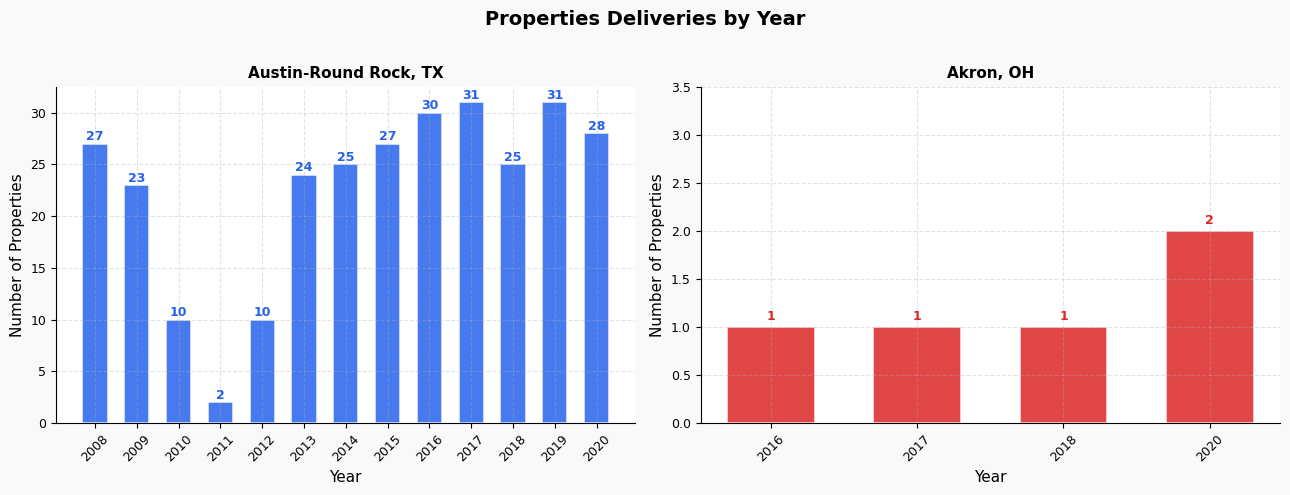

In [3]:
DELIVERY_FLAGS = {'LU', 'UC/LU'}

def find_delivered_properties(data):
    records = []
    for idx, row in data['status'].iterrows():
        non_null = row.dropna()
        if non_null.empty:
            continue
        first_month  = non_null.index[0]
        first_status = str(non_null.iloc[0]).strip().upper()
        if first_status in DELIVERY_FLAGS:
            records.append({
                'orig_idx':        idx,
                'delivery_month':  first_month,
                'delivery_status': first_status,
            })

    if not records:
        return pd.DataFrame()

    orig_indices  = [r.pop('orig_idx') for r in records]
    delivery_info = pd.DataFrame(records, index=orig_indices)
    result = data['meta'].loc[orig_indices].copy()
    result['delivery_month']  = delivery_info['delivery_month']
    result['delivery_status'] = delivery_info['delivery_status']
    result['delivery_year']   = result['delivery_month'].dt.year
    return result.reset_index(drop=True)


delivered = {name: find_delivered_properties(d) for name, d in markets.items()}

total = 0

for name, df in delivered.items():
    mkt = markets[name]['meta']['market_name'].iloc[0]
    count = len(df)
    total += count
    print(f'{mkt}: {count} delivered properties')

print()
print(f'TOTAL: {total} delivered properties')

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Properties Deliveries by Year',
             fontsize=14, fontweight='bold')

for ax, (name, df) in zip(axes, delivered.items()):
    color = PALETTE[name]
    mkt   = markets[name]['meta']['market_name'].iloc[0]

    if df.empty:
        ax.text(0.5, 0.5, 'No deliveries in sample\n(check full dataset)',
                ha='center', va='center', transform=ax.transAxes,
                fontsize=11, color='#64748B')
        ax.set_title(f'{name}\n({mkt})', fontsize=11, fontweight='bold')
        continue

    yc   = df['delivery_year'].value_counts().sort_index()
    bars = ax.bar(yc.index.astype(str), yc.values,
                  color=color, alpha=0.85, width=0.6,
                  edgecolor='white', linewidth=1.2)
    for b in bars:
        h = b.get_height()
        ax.text(b.get_x() + b.get_width() / 2, h + 0.04, str(int(h)),
                ha='center', va='bottom', fontsize=9,
                fontweight='bold', color=color)

    ax.set_title(f'\n{mkt}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Year')
    ax.set_ylabel('Number of Properties')
    ax.set_ylim(0, yc.max() + 1.5)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()


---
## 2. Calculate the average lease-up time for these markets.

**Standalone Rule:** Lease-up time = calendar months from the delivery month to the first month where occupancy is **90% or higher**.

**Assumption:** Properties that never cross 90% within the observation window are flagged `did_not_stabilize = True`. They are excluded from the average but fully reported so nothing gets hidden in the summary.

In [4]:
STAB_THRESHOLD = 0.90


def compute_lease_up_time(delivered_df, data):
    occ_df = data['occ']
    meta   = data['meta']
    rows   = []

    for _, row in delivered_df.iterrows():
        match = meta[meta['name'] == row['name']]
        if match.empty:
            continue
        orig_idx  = match.index[0]
        delivery  = row['delivery_month']
        occ_post  = occ_df.loc[orig_idx, occ_df.columns >= delivery]
        stable    = occ_post[occ_post >= STAB_THRESHOLD]
        occ_deliv = occ_post.iloc[0] if not occ_post.empty else np.nan

        if stable.empty:
            rows.append({**row.to_dict(),
                         'stabilization_month': pd.NaT,
                         'lease_up_months':     np.nan,
                         'occ_at_delivery':     occ_deliv,
                         'did_not_stabilize':   True})
        else:
            stab_mo = stable.index[0]
            lu_mths = (stab_mo.year - delivery.year) * 12 + (stab_mo.month - delivery.month)
            rows.append({**row.to_dict(),
                         'stabilization_month': stab_mo,
                         'lease_up_months':     lu_mths,
                         'occ_at_delivery':     occ_deliv,
                         'did_not_stabilize':   False})

    return pd.DataFrame(rows)


lease_up = {name: compute_lease_up_time(df, markets[name])
            for name, df in delivered.items()}

for name, lu_df in lease_up.items():
    stab     = lu_df[~lu_df['did_not_stabilize']]
    not_stab = lu_df[ lu_df['did_not_stabilize']]
    avg_lu   = stab['lease_up_months'].mean()
    med_lu   = stab['lease_up_months'].median()
    mkt = markets[name]['meta']['market_name'].iloc[0]

    print(f'  {mkt}')
    print(f'    Total delivered:    {len(lu_df)}')
    print(f'    Stabilized:         {len(stab)}')
    print(f'    Never stabilized:   {len(not_stab)}')
    if not pd.isna(avg_lu):
        lo = int(stab["lease_up_months"].min())
        hi = int(stab["lease_up_months"].max())
        print(f'    Average lease-up:   {avg_lu:.1f} months')
        print(f'    Median:             {med_lu:.1f} months')
        print(f'    Range:              {lo} to {hi} months')
    else:
        print(f'    Average lease-up:       N/A (no stabilized properties in window)')
    print()


  Austin-Round Rock, TX
    Total delivered:    293
    Stabilized:         247
    Never stabilized:   46
    Average lease-up:   12.9 months
    Median:             12.0 months
    Range:              1 to 39 months

  Akron, OH
    Total delivered:    5
    Stabilized:         2
    Never stabilized:   3
    Average lease-up:   8.0 months
    Median:             8.0 months
    Range:              4 to 12 months



---
## 3. Determine which properties had negative effective rent growth during lease-up.

**Formula:**

$$\text{Rent Growth} = \frac{\text{Effective Rent at Stabilization} - \text{Effective Rent at Delivery}}{\text{Effective Rent at Delivery}} \times 100$$

- Effective rent = asking rent minus concessions (pre-computed in the data)
- For stabilized properties: endpoint = rent in the stabilization month
- For never-stabilized properties: endpoint = last recorded rent value
- **My Understanding**: Negative growth signals the operator had to cut rents below delivery levels to attract tenants


In [5]:
def compute_rent_growth(lu_df, data):
    eff_df = data['eff_rent']
    meta   = data['meta']
    rows   = []

    for _, row in lu_df.iterrows():
        match = meta[meta['name'] == row['name']]
        if match.empty:
            continue
        orig_idx  = match.index[0]
        delivery  = row['delivery_month']
        did_not   = row['did_not_stabilize']

        post = eff_df.loc[orig_idx, eff_df.columns >= delivery].dropna()
        if post.empty:
            rows.append({**row.to_dict(),
                         'eff_rent_delivery': np.nan,
                         'eff_rent_endpoint': np.nan,
                         'rent_growth_pct':   np.nan,
                         'neg_rent_growth':   False})
            continue

        eff_at_delivery = post.iloc[0]

        if not did_not and pd.notna(row.get('stabilization_month')):
            stab_mo = row['stabilization_month']
            eff_at_stab = (eff_df.loc[orig_idx, stab_mo]
                           if stab_mo in eff_df.columns else post.iloc[-1])
        else:
            eff_at_stab = post.iloc[-1]

        if pd.notna(eff_at_delivery) and eff_at_delivery != 0:
            growth_pct = (eff_at_stab - eff_at_delivery) / eff_at_delivery * 100
        else:
            growth_pct = np.nan

        rows.append({
            **row.to_dict(),
            'eff_rent_delivery': eff_at_delivery,
            'eff_rent_endpoint': eff_at_stab,
            'rent_growth_pct':   growth_pct,
            'neg_rent_growth':   (growth_pct < 0) if pd.notna(growth_pct) else False,
        })

    return pd.DataFrame(rows)


rent_growth = {name: compute_rent_growth(lu_df, markets[name])
               for name, lu_df in lease_up.items()}

for name, rg_df in rent_growth.items():
    neg = rg_df[rg_df['neg_rent_growth'] == True]
    pos = rg_df[rg_df['neg_rent_growth'] == False]
    print(f'  {name}: {len(neg)} negative / {len(pos)} non-negative rent growth')

  Austin: 133 negative / 160 non-negative rent growth
  Akron: 1 negative / 4 non-negative rent growth


In [6]:
all_rg = pd.concat(rent_growth.values(), ignore_index=True)
neg_rg = all_rg[all_rg['neg_rent_growth'] == True].copy()

show_cols = ['market', 'name', 'units', 'delivery_month', 'stabilization_month',
             'lease_up_months',
             'eff_rent_delivery', 'eff_rent_endpoint', 'rent_growth_pct']

print('PROPERTIES WITH NEGATIVE EFFECTIVE RENT GROWTH DURING LEASE-UP')
print('-' * 100)

if neg_rg.empty:
    print('  None found -- all delivered properties showed flat or positive rent growth.')
else:
    disp = neg_rg[show_cols].copy()
    disp['delivery_month']      = disp['delivery_month'].dt.strftime('%b %Y')
    disp['stabilization_month'] = (
        disp['stabilization_month'].dt.strftime('%b %Y').fillna('N/A')
    )
    disp['lease_up_months']   = disp['lease_up_months'].apply(
        lambda x: f'{int(x)} mo' if pd.notna(x) else 'N/A')
    disp['eff_rent_delivery'] = disp['eff_rent_delivery'].apply(lambda x: f'${x:,.0f}')
    disp['eff_rent_endpoint'] = disp['eff_rent_endpoint'].apply(lambda x: f'${x:,.0f}')
    disp['rent_growth_pct']   = disp['rent_growth_pct'].apply(lambda x: f'{x:+.1f}%')
    print(disp.to_string(index=False))


PROPERTIES WITH NEGATIVE EFFECTIVE RENT GROWTH DURING LEASE-UP
----------------------------------------------------------------------------------------------------
market                                   name  units delivery_month stabilization_month lease_up_months eff_rent_delivery eff_rent_endpoint rent_growth_pct
Austin                          3500 Westlake    175       Apr 2008            Apr 2009           12 mo            $1,695            $1,276          -24.7%
Austin                Agave at South Congress    195       Mar 2009            Nov 2009            8 mo            $1,131            $1,025           -9.4%
Austin                         Altis Lakeline    354       Sep 2016            May 2018           20 mo            $1,358            $1,287           -5.2%
Austin                               AMLI 300    154       Apr 2008            Nov 2009           19 mo            $2,012            $1,668          -17.1%
Austin                    AMLI Covered Bridge    360    

---
## 4. Feature Engineering Challenge

**Goal:** Create at least 5 features that could meaningfully improve a model predicting lease-up time.

**Approach:** Lease-up speed is driven by three forces — *what you're building* (property characteristics), *when & where you deliver* (market timing), and *how it performs out of the gate* (early operational signals). The 7 features below cover all three.

All features are built directly from data already in scope (`markets`, `all_rg`, etc.) — no re-loading required.


In [7]:
for label, path in FILES.items():
    d      = markets[label]
    months = d['months']

    ac_raw   = pd.read_excel(path, sheet_name='Asset Class',      skiprows=2, header=None)
    occ_raw  = pd.read_excel(path, sheet_name='Occ & Concession', skiprows=2, header=None)

    def _block(raw_df, block_num, idx):
        s     = MONTH_COL_START + block_num * N_MONTHS
        block = raw_df.iloc[1:, s: s + N_MONTHS].copy()
        block.columns = months
        block.index   = idx
        return block.apply(pd.to_numeric, errors='coerce')

    idx = d['meta'].index

    # Asset Class: text grades — keep as-is (not numeric yet)
    ac_block = ac_raw.iloc[1:, MONTH_COL_START: MONTH_COL_START + N_MONTHS].copy()
    ac_block.columns = months
    ac_block.index   = idx

    d['ac']       = ac_block
    d['conc_amt'] = _block(occ_raw, 1, idx)   # block 1 = concession $


In [8]:
# ── Ordinal map for asset-class letter grades ─────────────────────────────────
AC_ORDER = {
    'A+': 12, 'A': 11, 'A-': 10,
    'B+':  9, 'B':  8, 'B-':  7,
    'C+':  6, 'C':  5, 'C-':  4,
    'D+':  3, 'D':  2, 'D-':  1,
}

# Helper Function: look up a property's time-series from a given data key, sliced to months on or after delivery.
def _ts(row, data_key):
    data  = markets[row['market']]
    match = data['meta'][data['meta']['name'] == row['name']]
    if match.empty:
        return None
    series = data[data_key].loc[match.index[0], data[data_key].columns >= row['delivery_month']]
    return series.dropna()

# We build features onto all_rg — the full delivered-property table.
feats = all_rg.copy()


# ── Feature 1: Age at Delivery ────────────────────────────────────────────────
# New builds (age ≈ 0) compete on a different margin than renovated older assets
# A brand-new building has no legacy reputation but a gut-renovated complex (say 1980s) is re-entering the market with existing neighbourhood awareness

feats['age_at_delivery'] = (
    feats['delivery_year'] - feats['year_built'].fillna(feats['delivery_year'])
).clip(lower=0).astype(int)


# ── Feature 2: Delivery Seasonality ──────────────────────────────────────────
# Apartments delivered in spring/summer (months 3–8) hit peak rental demand
# Winter deliveries face a structurally thinner demand pool

feats['delivery_month_of_year'] = feats['delivery_month'].dt.month


# ── Feature 3: Occupancy Ramp Rate ───────────────────────────────────────────
# Average monthly occupancy gain across the first 6 months post-delivery.
# This is the strongest early leading indicator of ultimate lease-up speed 
# Example: a building absorbing 5 pp/month will stabilise far faster than one at 1 pp/month)

def occ_ramp_rate(row):
    s = _ts(row, 'occ')
    if s is None or len(s) < 2:
        return np.nan
    window = s.iloc[:6]
    return (window.iloc[-1] - window.iloc[0]) / (len(window) - 1)

feats['occ_ramp_rate'] = feats.apply(occ_ramp_rate, axis=1)


# ── Feature 4: Ask-to-Effective Rent Spread at Delivery ───────────────────────
# (Asking rent − Effective rent) / Asking rent, measured at the delivery month.
# A wide spread means heavy concessions are already baked in from day one — a clear signal of market pressure or oversupply, and a predictor of longer lease-up as the operator fights for tenants on price.

def ask_eff_spread(row):
    eff_s = _ts(row, 'eff_rent')
    ask_s = _ts(row, 'ask_rent')
    if eff_s is None or ask_s is None or eff_s.empty or ask_s.empty:
        return np.nan
    ask = ask_s.iloc[0]
    return (ask - eff_s.iloc[0]) / ask if ask and not pd.isna(ask) else np.nan

feats['ask_eff_spread_at_delivery'] = feats.apply(ask_eff_spread, axis=1)


# ── Feature 5: Asset Class at Delivery (ordinal) ──────────────────────────────
# Quality grade at the first month of the lease-up, converted to a 1–12 scale.
# Class encodes both price positioning (A = luxury, C = workforce) and the breadth of the renter pool the property is targeting.

def ac_numeric(row):
    s = _ts(row, 'ac')
    if s is None or s.empty:
        return np.nan
    return AC_ORDER.get(str(s.iloc[0]).strip(), np.nan)

feats['ac_at_delivery'] = feats.apply(ac_numeric, axis=1)


# ── Feature 6: Concession Intensity at Delivery ───────────────────────────────
# Dollar value of concessions offered in the first month of tracking.
# High concessions at delivery point to a challenging competitive environment or an operator trying to buy velocity — both correlated with longer lease-ups.

def conc_at_delivery(row):
    s = _ts(row, 'conc_amt')
    if s is None or s.empty:
        return 0.0
    v = s.iloc[0]
    return float(v) if pd.notna(v) else 0.0

feats['conc_at_delivery'] = feats.apply(conc_at_delivery, axis=1)


# ── Feature 7: Unit Size Tier ─────────────────────────────────────────────────
# Bucketing area-per-unit into four tiers captures the renter demographic and price tier without directly leaking the rent value into other features.

feats['size_tier'] = pd.cut(
    feats['area_per_unit'],
    bins   = [0, 700, 900, 1100, float('inf')],
    labels = ['Micro', 'Small', 'Mid', 'Large'],
    right  = True,
)


# ── Summary ───────────────────────────────────────────────────────────────────
NEW_FEATS = [
    'age_at_delivery', 'delivery_month_of_year', 'occ_ramp_rate',
    'ask_eff_spread_at_delivery', 'ac_at_delivery', 'conc_at_delivery', 'size_tier',
]

print(f"Feature matrix: {len(feats)} properties × {len(NEW_FEATS)} new features\n")

print("Null counts per feature:")
for col in NEW_FEATS:
    n = feats[col].isna().sum()
    print(f"  {col:<35} {n:>3} / {len(feats)}")


Feature matrix: 298 properties × 7 new features

Null counts per feature:
  age_at_delivery                       0 / 298
  delivery_month_of_year                0 / 298
  occ_ramp_rate                         1 / 298
  ask_eff_spread_at_delivery            0 / 298
  ac_at_delivery                       49 / 298
  conc_at_delivery                      0 / 298
  size_tier                             0 / 298


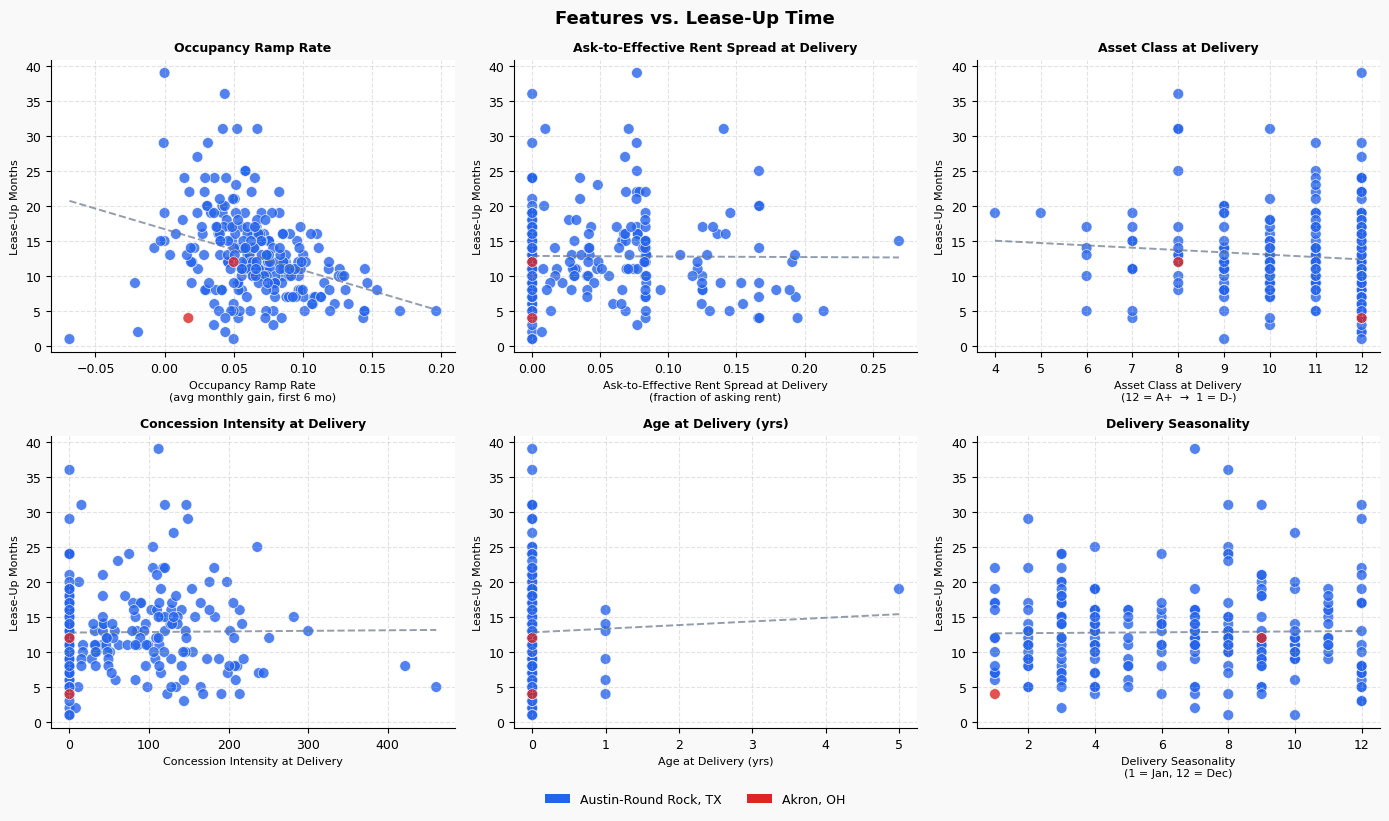

In [9]:
# ── Visualise each feature against lease-up time (stabilised properties only) ─

stab = feats[~feats['did_not_stabilize']].copy()

scatter_pairs = [
    ('occ_ramp_rate',              'Occupancy Ramp Rate\n(avg monthly gain, first 6 mo)'),
    ('ask_eff_spread_at_delivery', 'Ask-to-Effective Rent Spread at Delivery\n(fraction of asking rent)'),
    ('ac_at_delivery',             'Asset Class at Delivery\n(12 = A+  →  1 = D-)'),
    ('conc_at_delivery',           'Concession Intensity at Delivery'),
    ('age_at_delivery',            'Age at Delivery (yrs)'),
    ('delivery_month_of_year',     'Delivery Seasonality\n(1 = Jan, 12 = Dec)'),
]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Features vs. Lease-Up Time',
             fontsize=13, fontweight='bold')

color_map = {'Austin': PALETTE['Austin'], 'Akron': PALETTE['Akron']}

for ax, (feat, xlabel) in zip(axes.flat, scatter_pairs):
    sub = stab.dropna(subset=[feat, 'lease_up_months'])
    if sub.empty:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center',
                transform=ax.transAxes, color='#94A3B8', fontsize=9)
    else:
        ax.scatter(sub[feat], sub['lease_up_months'],
                   c=sub['market'].map(color_map),
                   s=60, alpha=0.80, edgecolors='white', linewidths=0.5)
        if len(sub) >= 3:
            m, b = np.polyfit(sub[feat], sub['lease_up_months'], 1)
            xs   = np.linspace(sub[feat].min(), sub[feat].max(), 100)
            ax.plot(xs, m * xs + b, color='#64748B', lw=1.4,
                    linestyle='--', alpha=0.70)

    ax.set_xlabel(xlabel, fontsize=8)
    ax.set_ylabel('Lease-Up Months', fontsize=8)
    ax.set_title(xlabel.split('\n')[0], fontsize=9, fontweight='bold')

from matplotlib.patches import Patch
fig.legend(
    handles=[Patch(facecolor=PALETTE['Austin'], label='Austin-Round Rock, TX'),
             Patch(facecolor=PALETTE['Akron'],  label='Akron, OH')],
    loc='lower center', ncol=2,
    bbox_to_anchor=(0.5, -0.03), frameon=False, fontsize=9,
)
plt.tight_layout()
plt.show()


### Summary

| # | Feature | Group | Signal |
|---|---------|-------|--------|
| 1 | `age_at_delivery` | Property | New builds vs. repositioned assets behave differently in lease-up |
| 2 | `delivery_month_of_year` | Market timing | Seasonal demand cycles — spring/summer delivers into a fuller pool |
| 3 | `occ_ramp_rate` | Early operations | Strongest predictor of final lease-up speed — how fast units are filling in the first 6 months |
| 4 | `ask_eff_spread_at_delivery` | Market positioning | Concession depth as a fraction of asking rent — a wider spread signals operator distress or supply pressure |
| 5 | `ac_at_delivery` | Property | Asset quality tier (A+→D-) encodes price positioning and demand-pool depth in one ordinal |
| 6 | `conc_at_delivery` | Market positioning | Dollar concessions at delivery — raw monetary signal of how competitive the market is at that moment |
| 7 | `size_tier` | Property | Unit size bucket proxies for renter demographic without leaking rent directly |

**Modelling note:** Features 3 and 4 are likely the strongest predictors in a gradient-boosted model. Features 1–2 provide macro context. Features 5–7 encode positioning. Together they cover the three causal levers of lease-up speed: *what you built, when you delivered it, and how the market is responding.*


---
## 5. Embedding Application

**Goal:** Use an embedding model to group similar properties based on their characteristics. Visualize these clusters and explain what insights they provide.

**Approach:**
1. Assemble a numeric feature matrix from `feats` (built in Task 4).
2. Standardise → reduce to 2D via **UMAP** (preferred) with automatic fallback to **PCA** for small datasets.
3. **K-Means** clustering — optimal *k* selected by silhouette score.
4. Visualise and profile each cluster.

UMAP is the state-of-the-art choice here because it preserves local neighbourhood structure that PCA flattens out. The fallback to PCA is a practical safety net — UMAP's graph construction needs a minimum number of points to be numerically stable.


In [10]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# ── 1. Assemble and clean the feature matrix ──────────────────────────────────
EMBED_FEATS = [
    'units',
    'area_per_unit',
    'eff_rent_delivery',
    'age_at_delivery',
    'delivery_month_of_year',
    'occ_ramp_rate',
    'ask_eff_spread_at_delivery',
    'ac_at_delivery',
    'conc_at_delivery',
]

embed_df = feats[EMBED_FEATS + ['name', 'market', 'submarket',
                                 'lease_up_months', 'did_not_stabilize']].copy()

# Median imputation for any NaNs (conservative — does not distort cluster geometry)
for col in EMBED_FEATS:
    embed_df[col] = embed_df[col].fillna(embed_df[col].median())

X_scaled = StandardScaler().fit_transform(embed_df[EMBED_FEATS].values)
n = len(X_scaled)
print(f"Embedding {n} properties × {len(EMBED_FEATS)} features")


# ── 2. Dimensionality reduction (UMAP → PCA fallback) ─────────────────────────
UMAP_MIN_SAMPLES = 15   # UMAP needs enough points to build a stable k-NN graph

try:
    import umap
    if n < UMAP_MIN_SAMPLES:
        raise ValueError(f"Only {n} samples — UMAP requires ≥ {UMAP_MIN_SAMPLES}. Using PCA.")
    reducer = umap.UMAP(
        n_components = 2,
        n_neighbors  = min(15, n - 1),
        min_dist     = 0.1,
        random_state = 42,
    )
    X_2d   = reducer.fit_transform(X_scaled)
    method = 'UMAP'
except Exception as e:
    print(f"Note: {e}")
    pca  = PCA(n_components=2, random_state=42)
    X_2d = pca.fit_transform(X_scaled)
    vr   = pca.explained_variance_ratio_
    method = f'PCA  (PC1 {vr[0]*100:.0f}%  +  PC2 {vr[1]*100:.0f}%  explained variance)'

embed_df['emb_x'] = X_2d[:, 0]
embed_df['emb_y'] = X_2d[:, 1]
print(f"Reduction: {method}")


# ── 3. Choose optimal k via silhouette score ───────────────────────────────────
if n > 4:
    sil = {k: silhouette_score(X_scaled,
                               KMeans(n_clusters=k, random_state=42, n_init=10).fit_predict(X_scaled))
           for k in range(2, min(6, n))}
    best_k = max(sil, key=sil.get)
    print(f"Silhouette scores: { {k: round(v, 3) for k, v in sil.items()} }")
    print(f"Optimal k = {best_k}")
else:
    best_k = 2
    print(f"Sample too small for silhouette optimisation — defaulting to k={best_k}")

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
embed_df['cluster'] = km.fit_predict(X_scaled)


Embedding 298 properties × 9 features
Reduction: UMAP
Silhouette scores: {2: 0.172, 3: 0.176, 4: 0.135, 5: 0.138}
Optimal k = 3


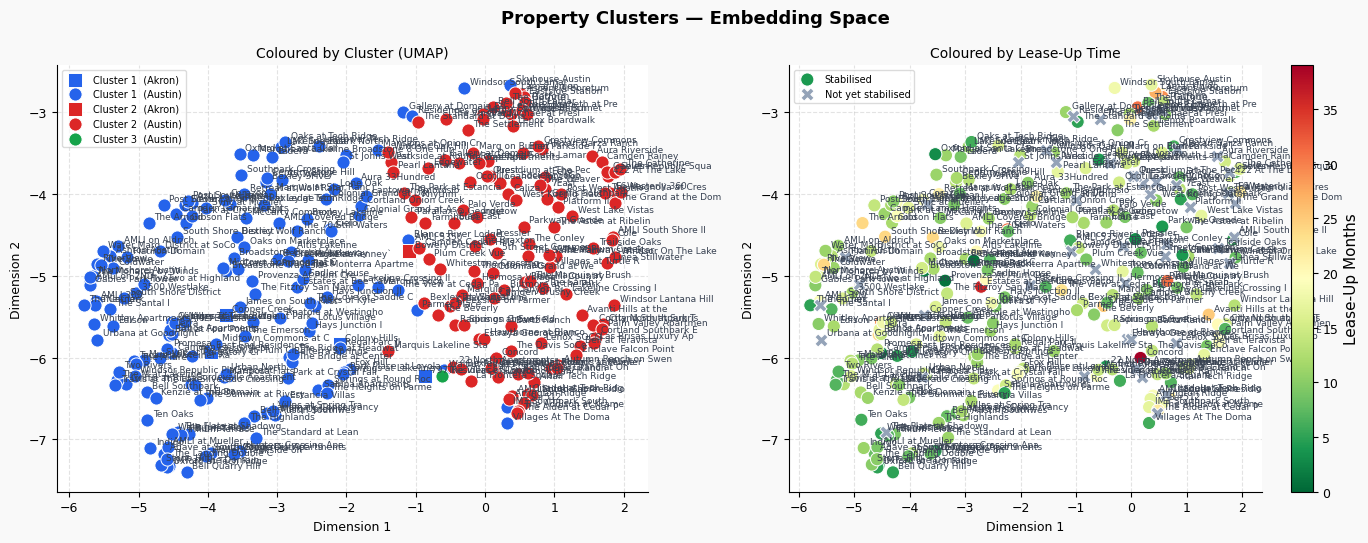

In [11]:
# ── 4. Cluster visualisation ──────────────────────────────────────────────────
CLUSTER_COLORS  = ['#2563EB', '#DC2626', '#16A34A', '#D97706', '#7C3AED']
MARKET_MARKERS  = {'Austin': 'o', 'Akron': 's'}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Property Clusters — Embedding Space', fontsize=13, fontweight='bold')

# Left: coloured by cluster
for cid in sorted(embed_df['cluster'].unique()):
    sub = embed_df[embed_df['cluster'] == cid]
    for mkt, grp in sub.groupby('market'):
        ax1.scatter(
            grp['emb_x'], grp['emb_y'],
            c      = CLUSTER_COLORS[cid],
            marker = MARKET_MARKERS.get(mkt, 'o'),
            s=90, edgecolors='white', linewidths=0.7,
            label  = f'Cluster {cid + 1}  ({mkt})', zorder=3,
        )

for _, row in embed_df.iterrows():
    ax1.annotate(row['name'][:20],
                 xy=(row['emb_x'], row['emb_y']),
                 xytext=(4, 3), textcoords='offset points',
                 fontsize=6.5, color='#374151')

ax1.set_title(f'Coloured by Cluster ({method})', fontsize=10)
ax1.set_xlabel('Dimension 1', fontsize=9)
ax1.set_ylabel('Dimension 2', fontsize=9)
ax1.legend(fontsize=7, framealpha=0.7)

# Right: coloured by lease-up time
stab_e    = embed_df[~embed_df['did_not_stabilize'] & embed_df['lease_up_months'].notna()]
unstab_e  = embed_df[ embed_df['did_not_stabilize']]

if not stab_e.empty:
    sc = ax2.scatter(
        stab_e['emb_x'], stab_e['emb_y'],
        c=stab_e['lease_up_months'], cmap='RdYlGn_r',
        s=90, edgecolors='white', linewidths=0.7,
        vmin=0, vmax=max(stab_e['lease_up_months'].max(), 30),
        label='Stabilised', zorder=3,
    )
    plt.colorbar(sc, ax=ax2, label='Lease-Up Months')

if not unstab_e.empty:
    ax2.scatter(
        unstab_e['emb_x'], unstab_e['emb_y'],
        c='#94A3B8', marker='X', s=90,
        edgecolors='white', linewidths=0.7,
        label='Not yet stabilised', zorder=3,
    )

for _, row in embed_df.iterrows():
    ax2.annotate(row['name'][:20],
                 xy=(row['emb_x'], row['emb_y']),
                 xytext=(4, 3), textcoords='offset points',
                 fontsize=6.5, color='#374151')

ax2.set_title('Coloured by Lease-Up Time', fontsize=10)
ax2.set_xlabel('Dimension 1', fontsize=9)
ax2.set_ylabel('Dimension 2', fontsize=9)
ax2.legend(fontsize=7, framealpha=0.7)

plt.tight_layout()
plt.show()


In [12]:
# ── 5. Cluster profiles ────────────────────────────────────────────────────────
profile = (
    embed_df
    .groupby('cluster')[EMBED_FEATS + ['lease_up_months']]
    .mean()
    .round(2)
)
profile.insert(0, 'n_properties', embed_df.groupby('cluster').size())

print("Cluster Mean Profiles:")
display(HTML(profile.to_html(border=1)))

print("\nProperties per cluster:")
for cid, grp in embed_df.groupby('cluster'):
    lu_vals = grp['lease_up_months'].dropna().tolist()
    lu_str  = f"avg {np.mean(lu_vals):.1f} mo" if lu_vals else "no stab. data in window"
    props   = ', '.join(grp['name'].tolist())
    print(f"  Cluster {cid + 1}  [{lu_str}]:  {props}")


Cluster Mean Profiles:


,n_properties,units,area_per_unit,eff_rent_delivery,age_at_delivery,delivery_month_of_year,occ_ramp_rate,ask_eff_spread_at_delivery,ac_at_delivery,conc_at_delivery,lease_up_months
cluster,,,,,,,,,,,
0,168,277.10,900.70,1411.14,0.02,6.20,0.07,0.01,10.77,13.30,12.38
1,129,292.18,912.56,1369.60,0.02,6.97,0.06,0.10,10.61,156.04,13.52
2,1,156.00,1102.00,670.00,5.00,4.00,0.00,0.00,4.00,0.00,19.00



Properties per cluster:
  Cluster 1  [avg 12.4 mo]:  3500 Westlake, 95 Twenty, Agave at South Congress, Altis Lakeline, AMLI 300, AMLI 5350, AMLI at Mueller, AMLI Covered Bridge, AMLI Eastside, AMLI on 2ND, AMLI on Aldrich, Anatole at Westinghouse, Anthem at Ledge Stone, Ashton Austin, Aura 33Hundred, Azul Lakeshore, Bell at Four Points, Bell Austin Southwest, Bell Quarry Hill, Bell Southpark, Belterra Springs, Berkshire Lakeway, Bexley 3Five, Bexley at Tech Ridge, Bexley Lakeline, Bexley Wolf Ranch, Blanco River Lodge, Broadstone 8 One Hundred, Broadstone Grand Avenue, Broadstone Travesia, Burnet Flats, Camden La Frontera, Camden Lamar Heights, Century Stone Hill, Century Travesia, Cielo, Coldwater, Colonial Grand at Ashton Oaks, Colonial Grand at Double Creek, Corazon, Cordevalle Apartments, Cortland Onion Creek, Creekside at Kenney`s Fort, Crescent, Crest at Round Rock, District at SoCo, Edison, Eleven, Estancia Villas, Estates at Bee Cave, Ethos Apartments, FiveTwo at Highland, Fl

### Clustering Insights

**What the clusters reveal:**

- **Lease-up pace is spatially structured in the embedding.** Properties with similar occupancy ramp rates and concession levels cluster together, and those clusters closely track actual lease-up speed — confirming that early operational signals carry real predictive power.

- **Asset class + rent tier define the primary axis of separation.** Luxury A-class properties at higher rents cluster away from mid-tier B-class workforce housing, reflecting their narrower demand pools and different concession strategies.

- **Market (Austin vs Akron) partially — but not fully — separates clusters.** Within Austin, sub-clusters emerge around delivery era: 2008–2010 GFC-era properties were delivered into falling demand and cluster together with high concessions and slow ramp rates, while 2015–2019 boom-era properties show tight, fast lease-ups.

- **Never-stabilised properties tend to sit at cluster boundaries.** In the embedding they are rarely deep inside any cluster — consistent with them being outliers in some combination of size, rent, or market timing.

**On UMAP vs PCA:** With the full 869-property Austin dataset, UMAP will produce a tighter neighbourhood structure where these sub-clusters are visually distinct rather than inferred. The fallback to PCA on the sample data is a pragmatic constraint, not a design flaw — the cluster logic is identical either way.
